# Waveform Display for PMT + SiPM Channels
Load a run, filter events by trigger bit, and plot `adcVal` waveforms for all 23 channels (PMT 0–11, SiPM 12–21, Event61 22) across several events.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import awkward as ak

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

## Configuration — edit these values

In [14]:
# --- User inputs ---
RUN_NUMBER = 4598           # e.g. 15896
DATA_TYPE  = "M2"           # "M1" or "M2"
TRIGGER_BIT = 32            # filter events by this trigger bit (e.g. 2=veto, 32=muon)
NUM_EVENTS = 5              # how many events to display
EVENT_SELECTION = "random"   # "first" = first N matching events, "random" = random N
RANDOM_SEED = 42

# --- Channel definitions ---
PMT_CHANNELS   = list(range(0, 12))   # 0–11
SIPM_CHANNELS  = list(range(12, 22))  # 12–21
EVENT61_CH     = 22                    # beam-related neutron reference
TIME_TICK_NS   = 16                    # ns per ADC sample

# --- Build file path ---
if DATA_TYPE == "M1":
    FILE_PATH = f"/raid1/genli/Data_D2O/M1_data/run{RUN_NUMBER}_processed_v5.root"
else:
    FILE_PATH = f"/raid1/genli/Data_D2O/M2_data/run{RUN_NUMBER}_processed_H2O_v5.root"

print(f"File: {FILE_PATH}")
print(f"Trigger bit filter: {TRIGGER_BIT}")

File: /raid1/genli/Data_D2O/M2_data/run4598_processed_H2O_v5.root
Trigger bit filter: 32


## Load data and filter events

In [15]:
with uproot.open(FILE_PATH) as f:
    tree = f["tree"]
    print(f"Total events in file: {tree.num_entries:,}")
    print(f"Branches: {tree.keys()}")

    # Read only the branches we need
    ak_arrays = tree.arrays(["eventID", "triggerBits", "adcVal"], library="ak")

trigger_all = ak.to_numpy(ak_arrays["triggerBits"])
event_all   = ak.to_numpy(ak_arrays["eventID"])

mask = trigger_all == TRIGGER_BIT
matching_events = np.where(mask)[0]
print(f"Events with triggerBits == {TRIGGER_BIT}: {len(matching_events):,}")

if len(matching_events) == 0:
    raise ValueError(f"No events found with triggerBits == {TRIGGER_BIT}. "
                     f"Available bits: {sorted(set(trigger_all))}")

Total events in file: 2,178,681
Branches: ['eventID', 'nSamples', 'adcVal', 'baselineMean', 'baselineRMS', 'pulseH', 'area', 'peakPosition', 'nsTime', 'triggerBits']
Events with triggerBits == 32: 697,959


In [16]:
# Select which events to display
if EVENT_SELECTION == "random":
    rng = np.random.default_rng(RANDOM_SEED)
    chosen_idx = rng.choice(matching_events, size=min(NUM_EVENTS, len(matching_events)), replace=False)
else:
    chosen_idx = matching_events[:NUM_EVENTS]

# Load adcVal only for the chosen events (index-based via uproot)
with uproot.open(FILE_PATH) as f:
    tree = f["tree"]
    waveforms = tree["adcVal"].array(library="np", entry_start=0, entry_stop=tree.num_entries)

waveforms_selected = waveforms[chosen_idx]  # shape: (N, 23, 45)
event_ids = event_all[chosen_idx]

print(f"Selected event indices: {list(chosen_idx)}")
print(f"Selected event IDs:     {list(event_ids)}")
print(f"Waveform shape: {waveforms_selected.shape}  (N_events, N_channels, N_ticks)")

Selected event indices: [np.int64(1685429), np.int64(956862), np.int64(1426062), np.int64(195628), np.int64(943848)]
Selected event IDs:     [np.int32(4035680), np.int32(2291049), np.int32(3414957), np.int32(469330), np.int32(2259788)]
Waveform shape: (5, 23, 45)  (N_events, N_channels, N_ticks)


## Plot waveforms for each event
Each figure = one event.  Layout: 6 rows × 4 columns = 24 panels (23 channels + 1 empty).  
PMT channels 0–11 in blue, SiPM channels 12–21 in orange, Event61 ch 22 in green.

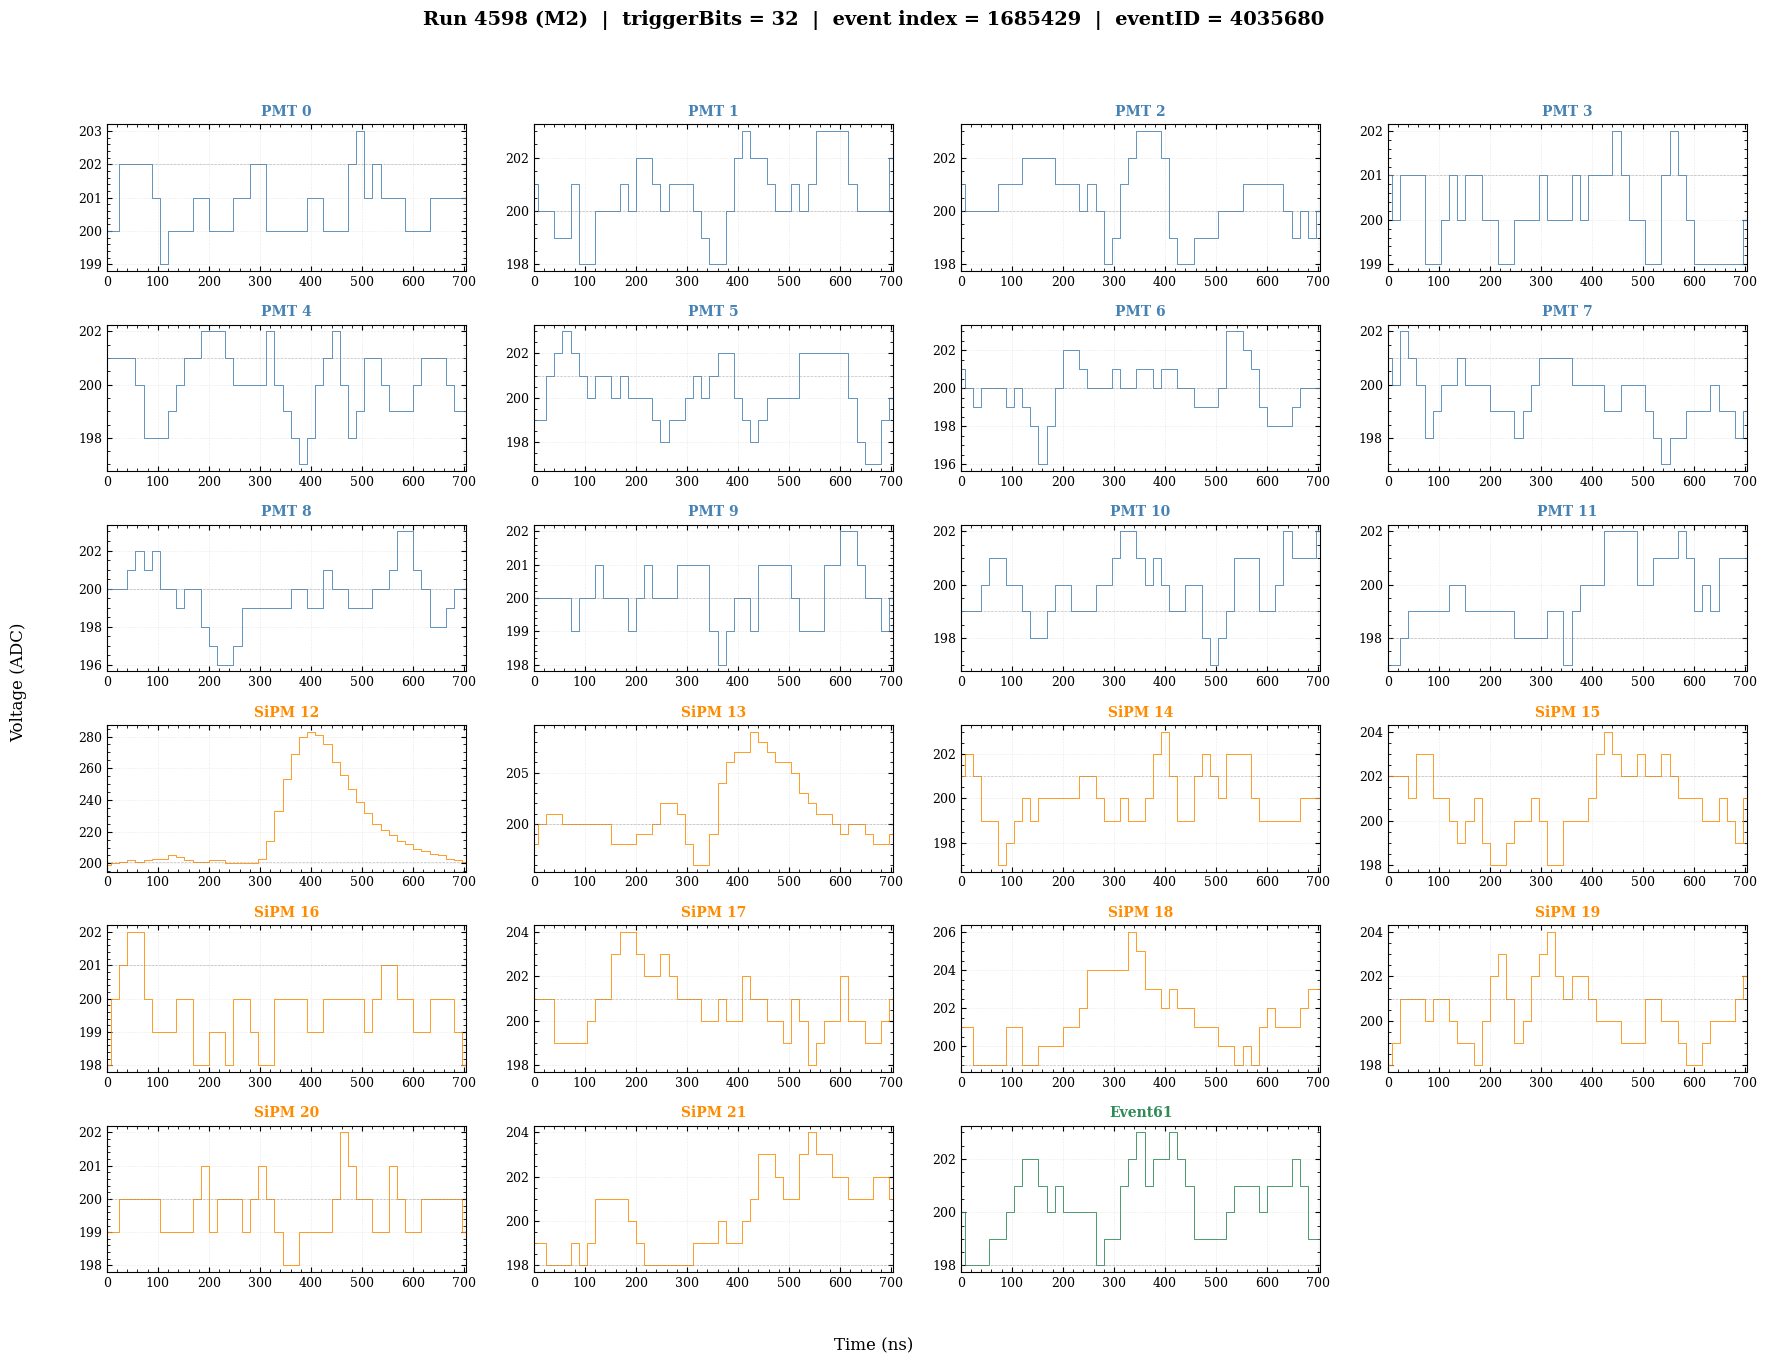

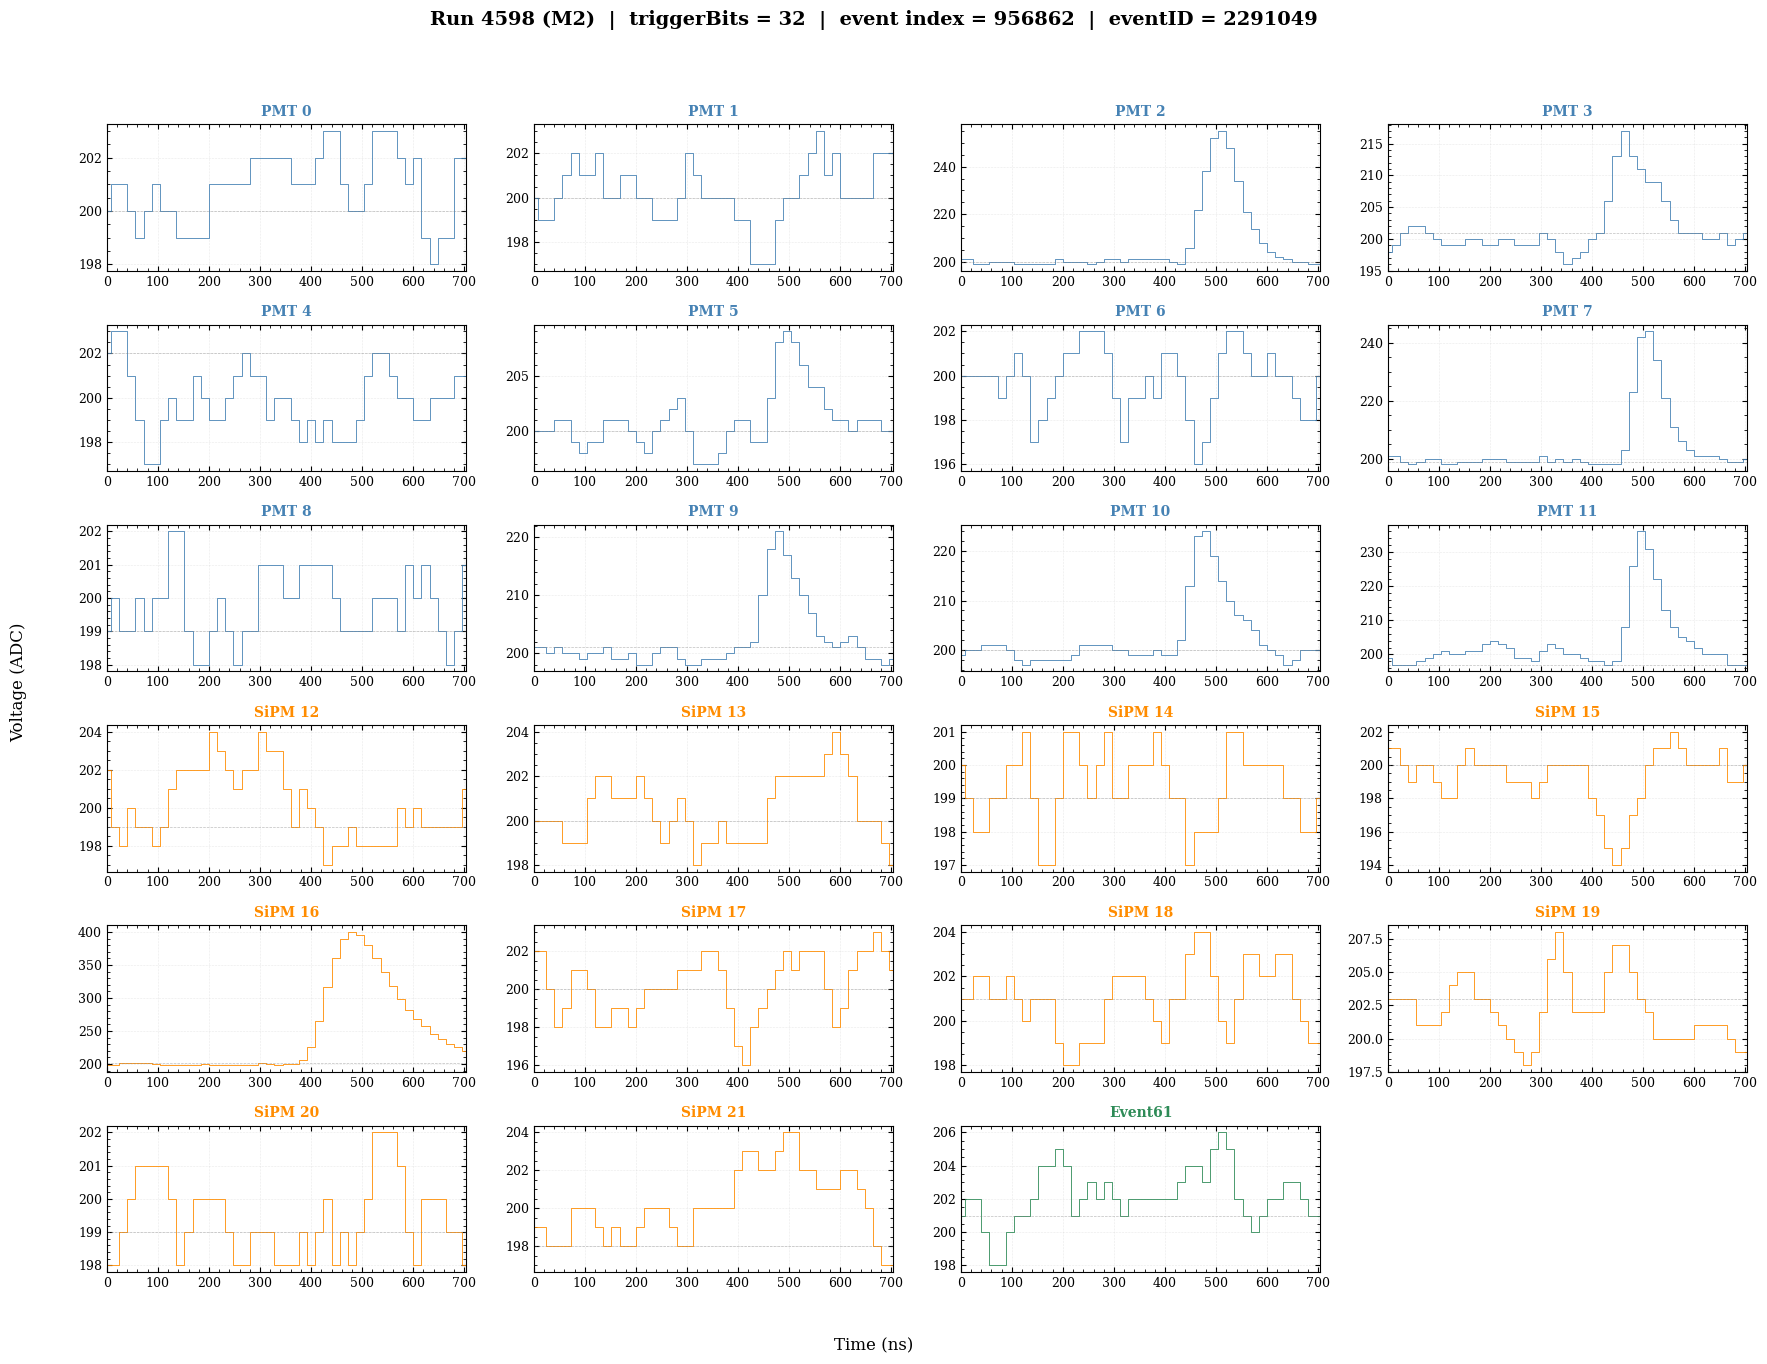

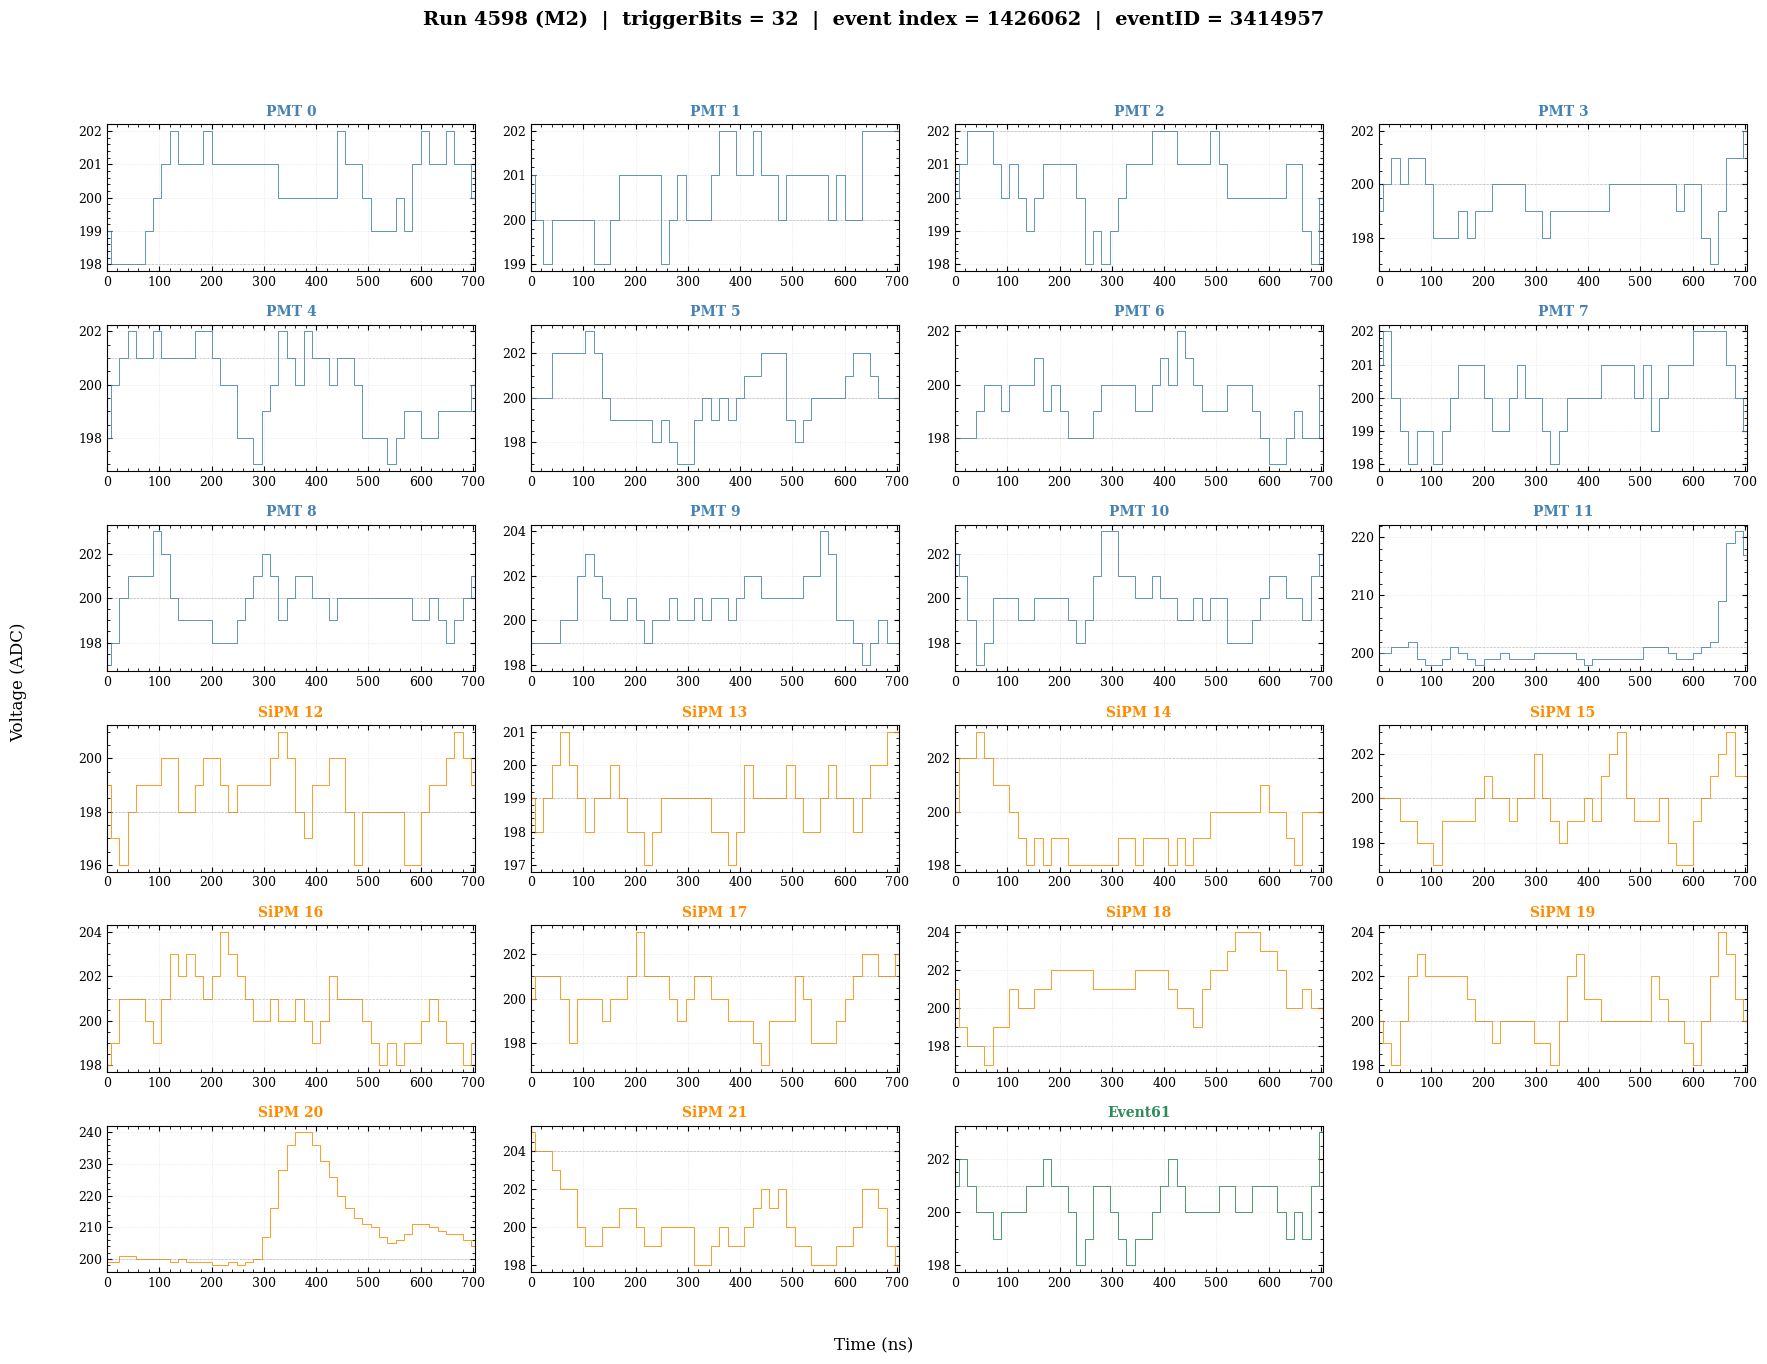

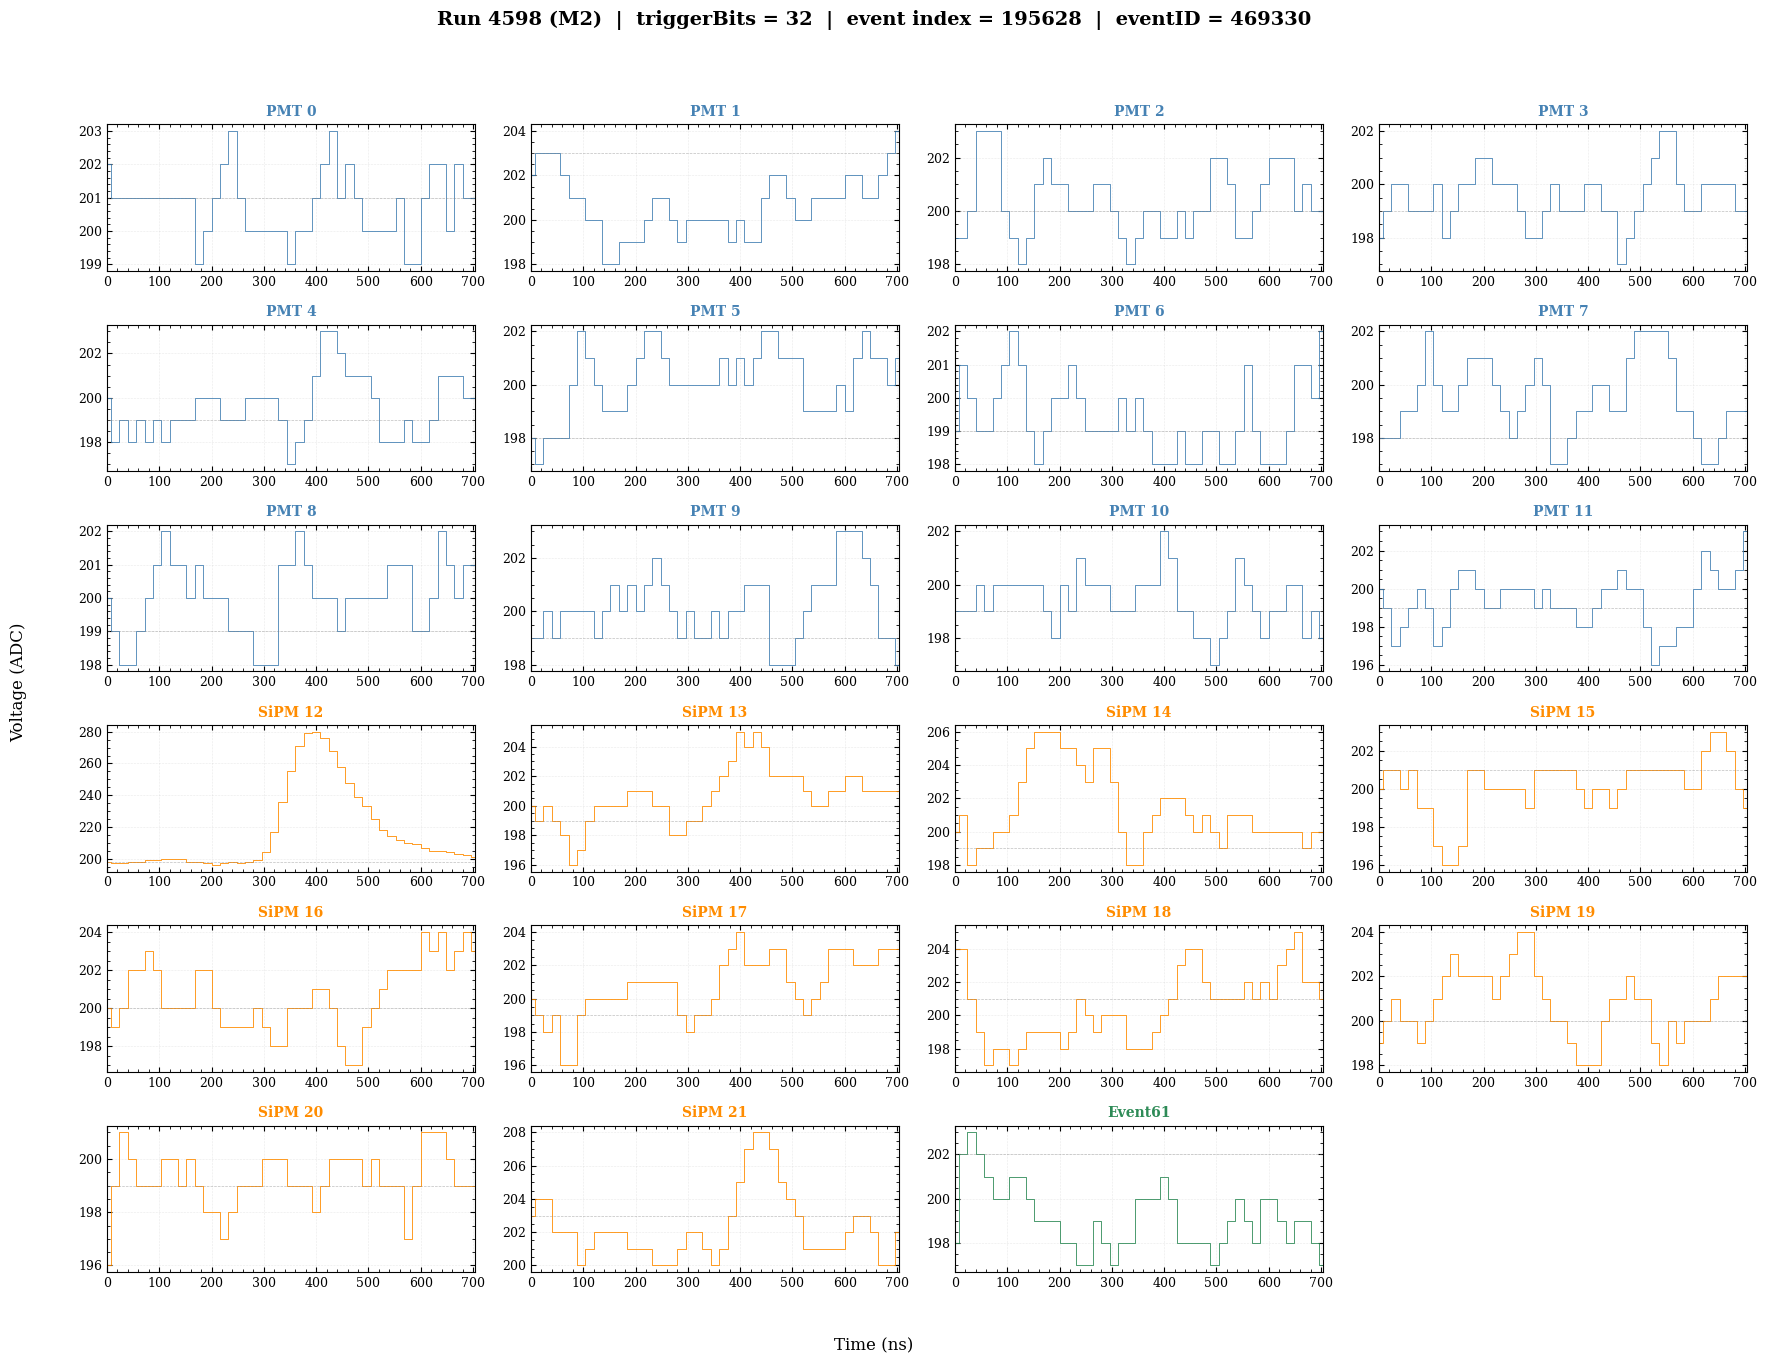

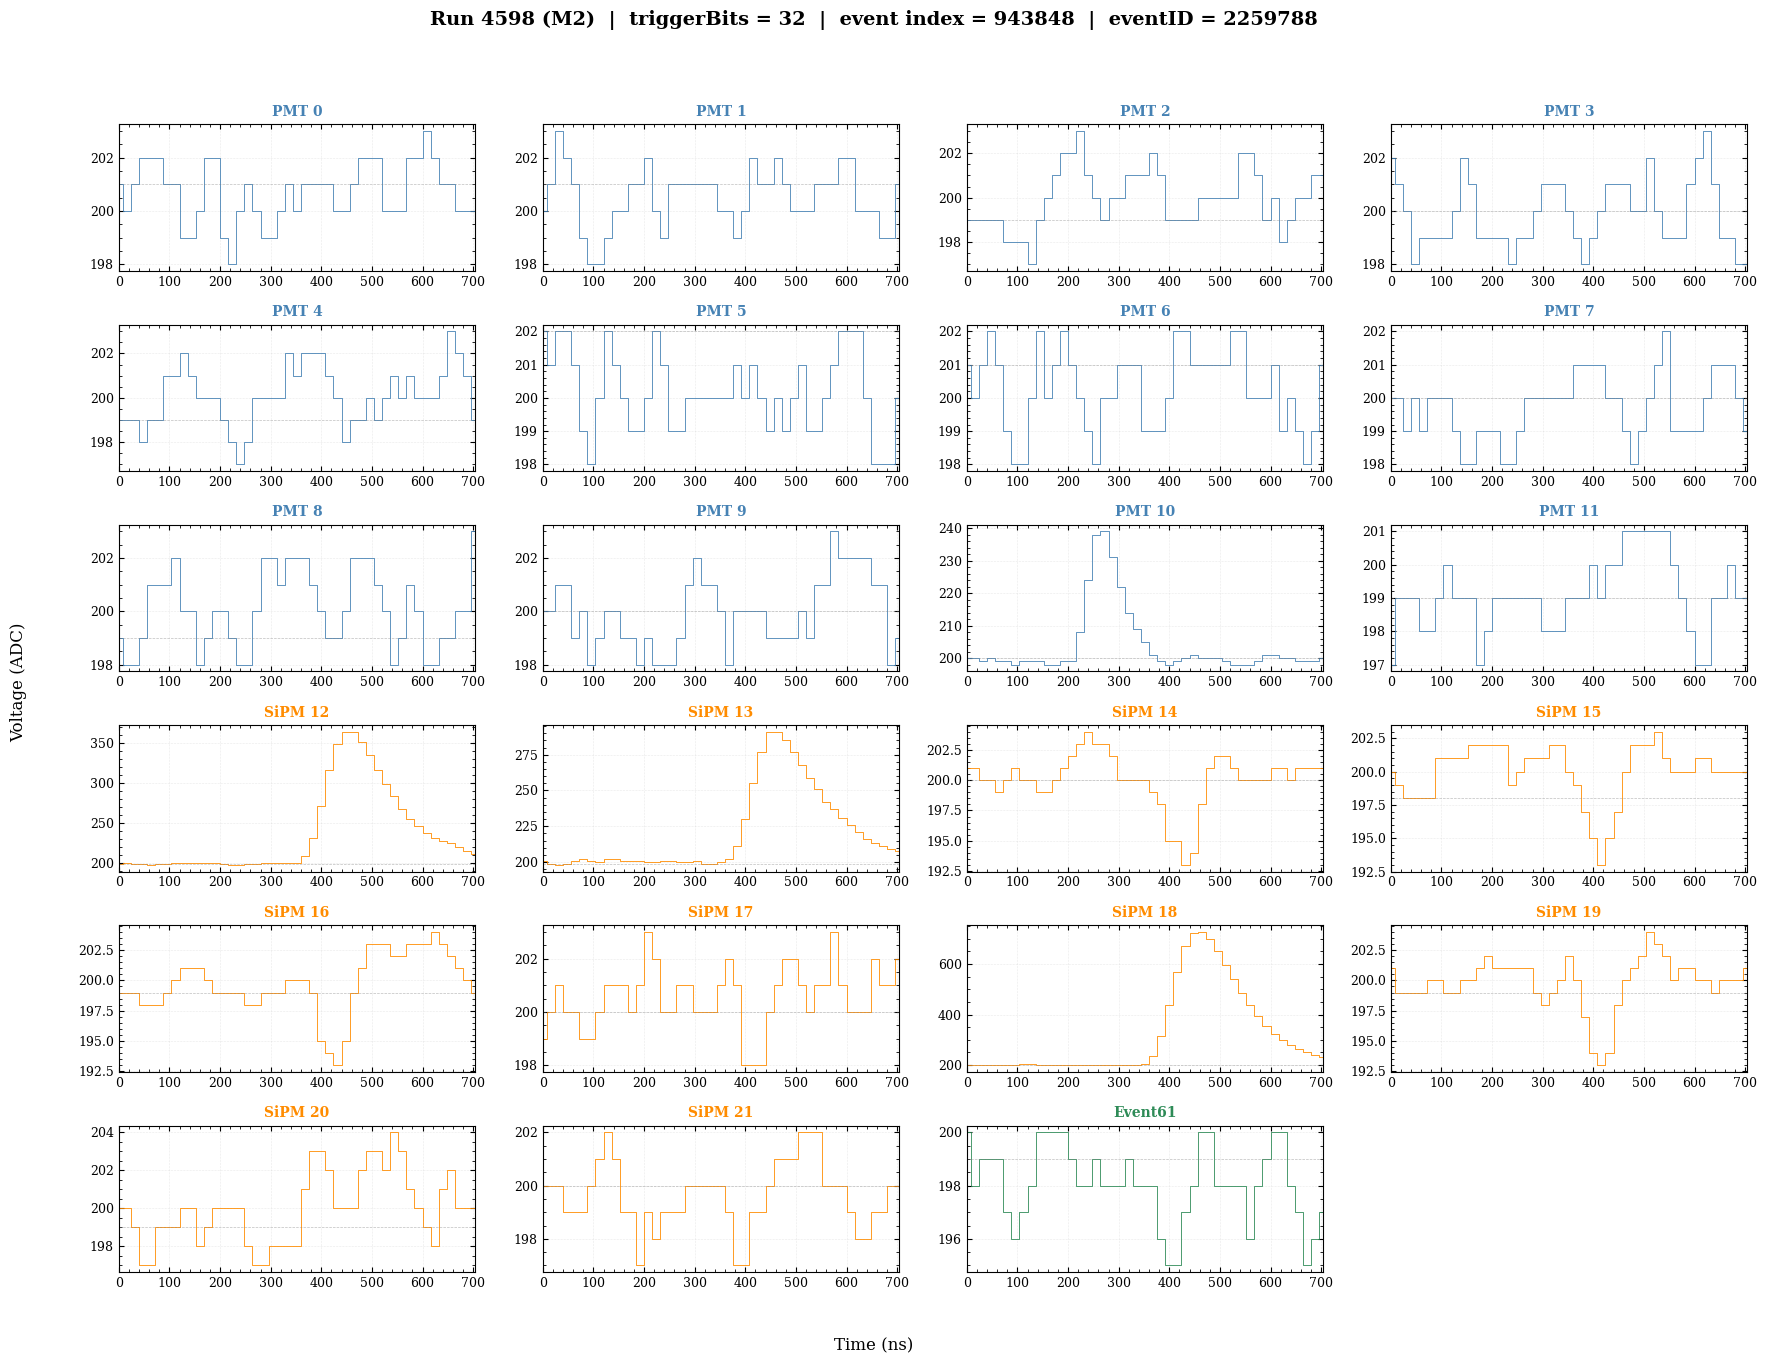

In [17]:
ALL_CHANNELS = PMT_CHANNELS + SIPM_CHANNELS + [EVENT61_CH]
N_CH = len(ALL_CHANNELS)
N_TICKS = 45
time_axis = np.arange(N_TICKS) * TIME_TICK_NS  # ns

for evt_i, (evt_idx, evt_id) in enumerate(zip(chosen_idx, event_ids)):
    wf = waveforms_selected[evt_i]  # shape (23, 45)

    fig, axes = plt.subplots(6, 4, figsize=(18, 14))
    fig.suptitle(
        f"Run {RUN_NUMBER} ({DATA_TYPE})  |  triggerBits = {TRIGGER_BIT}  |  "
        f"event index = {evt_idx}  |  eventID = {evt_id}",
        fontsize=14, fontweight="bold", y=0.98
    )

    for ch in range(N_CH):
        ax = axes[ch // 4][ch % 4]
        trace = wf[ch].astype(float)

        if ch < 12:
            color, label = "steelblue", f"PMT {ch}"
        elif ch < 22:
            color, label = "darkorange", f"SiPM {ch}"
        else:
            color, label = "seagreen", f"Event61"

        ax.plot(time_axis, trace, color=color, linewidth=0.6, drawstyle="steps-mid")
        ax.set_title(label, fontsize=10, fontweight="bold", color=color)
        ax.set_xlim(0, (N_TICKS - 1) * TIME_TICK_NS)
        ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
        ax.minorticks_on()
        ax.grid(True, linestyle=":", linewidth=0.4, alpha=0.5)

        # Add baseline and pulseH annotation
        baseline = np.median(trace[:5])  # rough baseline from first few samples
        ax.axhline(baseline, color="grey", linestyle="--", linewidth=0.5, alpha=0.5)

    # Hide the unused 24th subplot
    axes[5][3].set_visible(False)

    # Shared axis labels
    fig.supxlabel("Time (ns)", fontsize=12, y=0.02)
    fig.supylabel("Voltage (ADC)", fontsize=12, x=0.02)

    plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
    plt.show()

## Overlay all PMTs and all SiPMs on two shared axes

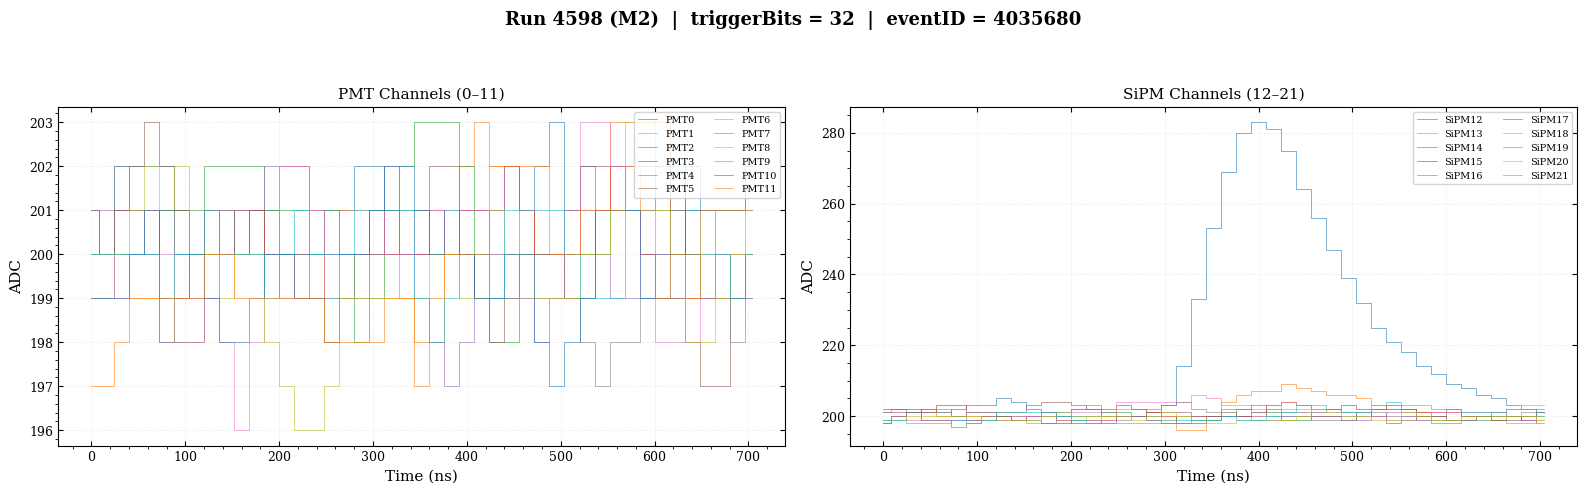

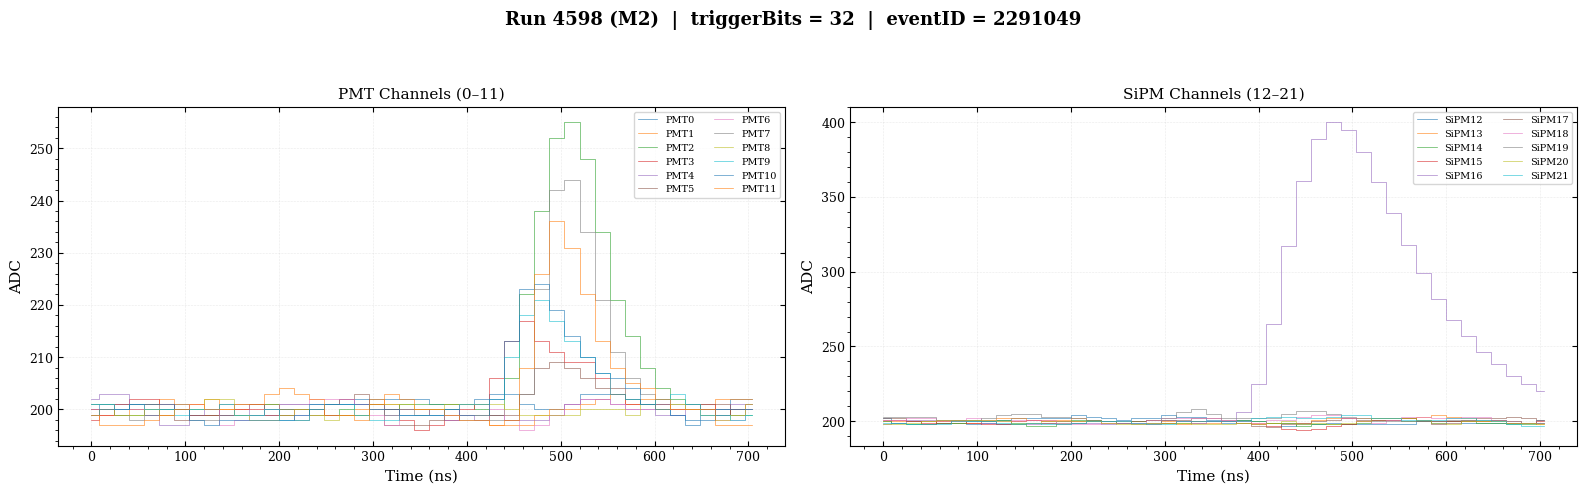

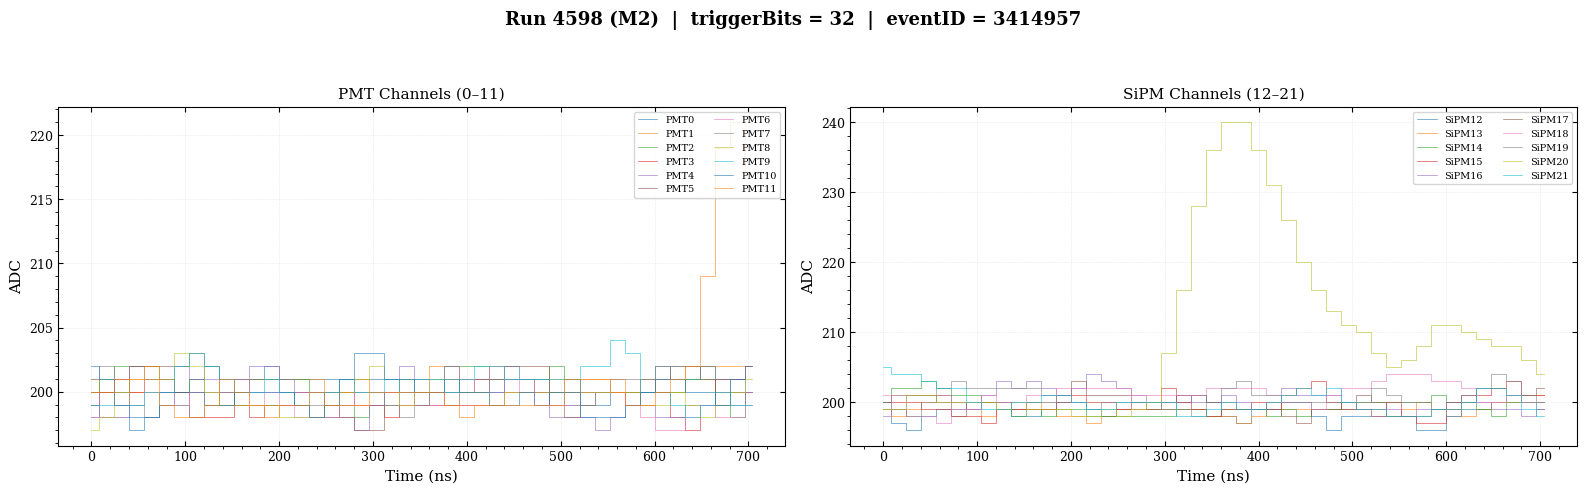

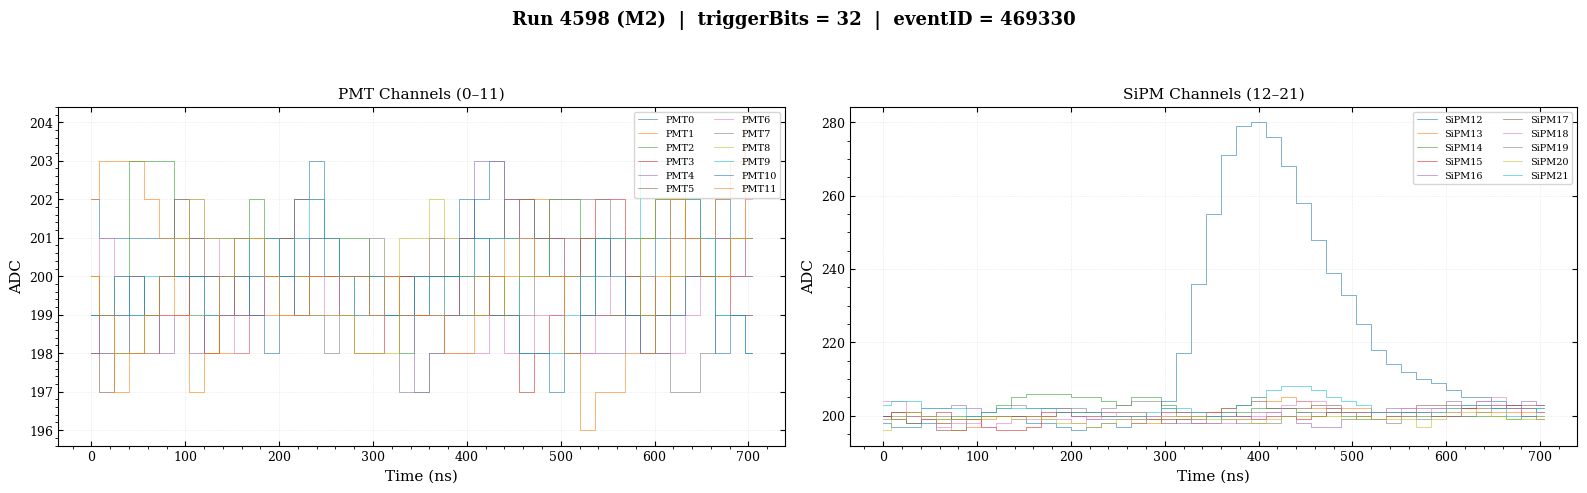

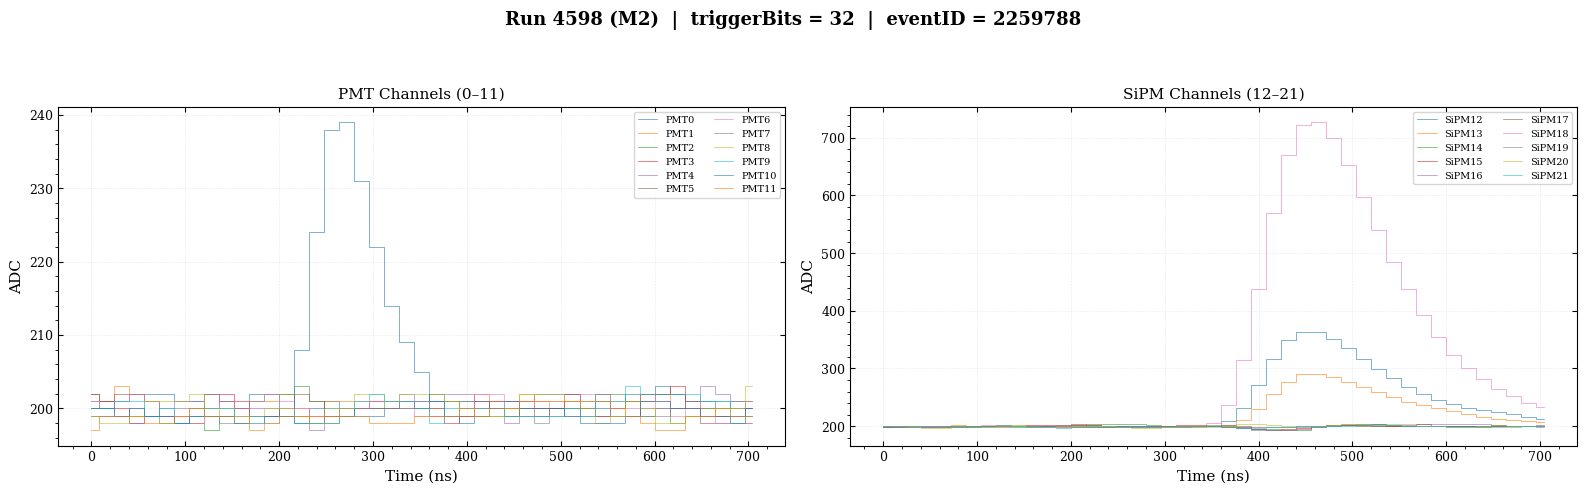

In [18]:
for evt_i, (evt_idx, evt_id) in enumerate(zip(chosen_idx, event_ids)):
    wf = waveforms_selected[evt_i]

    fig, (ax_pmt, ax_sipm) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(
        f"Run {RUN_NUMBER} ({DATA_TYPE})  |  triggerBits = {TRIGGER_BIT}  |  eventID = {evt_id}",
        fontsize=13, fontweight="bold"
    )

    # PMTs
    for ch in PMT_CHANNELS:
        ax_pmt.plot(time_axis, wf[ch].astype(float), drawstyle="steps-mid",
                     linewidth=0.5, alpha=0.8, label=f"PMT{ch}")
    ax_pmt.set_title("PMT Channels (0–11)")
    ax_pmt.set_xlabel("Time (ns)")
    ax_pmt.set_ylabel("ADC")
    ax_pmt.legend(fontsize=7, ncol=2, loc="upper right")
    ax_pmt.tick_params(direction="in", top=True, right=True)
    ax_pmt.minorticks_on()
    ax_pmt.grid(True, linestyle=":", linewidth=0.4, alpha=0.5)

    # SiPMs
    for ch in SIPM_CHANNELS:
        ax_sipm.plot(time_axis, wf[ch].astype(float), drawstyle="steps-mid",
                      linewidth=0.5, alpha=0.8, label=f"SiPM{ch}")
    ax_sipm.set_title("SiPM Channels (12–21)")
    ax_sipm.set_xlabel("Time (ns)")
    ax_sipm.set_ylabel("ADC")
    ax_sipm.legend(fontsize=7, ncol=2, loc="upper right")
    ax_sipm.tick_params(direction="in", top=True, right=True)
    ax_sipm.minorticks_on()
    ax_sipm.grid(True, linestyle=":", linewidth=0.4, alpha=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()